# AI-Gated + Graph-Filtered Markowitz Portfolio (2023-2025)

**Strategi Gabungan (Option 1):**
1.  **AI Gatekeeper**: Menggunakan Random Forest (dilatih pada data 2023-2024) untuk memprediksi rezim pasar (Bull/Bear) pada tahun 2025.
2.  **Graph-Based Asset Selection**: Jika AI memprediksi **Bull**:
    -   Kita tidak langsung mengoptimalkan *semua* aset.
    -   Kita membangun **Temporal Correlation Graph** (window 30 hari).
    -   Kita mencari **Maximum Independent Set (MIS)** untuk mendapatkan aset yang *tidak berkorelasi*.
    -   Hanya aset hasil filter MIS ini yang masuk ke optimasi Markowitz.
3.  **Risk-Off**: Jika AI memprediksi **Bear**, seluruh portofolio dialihkan ke Cash (Stablecoin/USD).

**Tujuan:** Menciptakan portofolio yang tidak hanya 'risk-on/risk-off', tapi juga 'structurally diversified' saat fase Risk-On.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Data Loading & Preparation
Mengambil data 2023-2025 untuk 24 aset kripto. Cek file lokal dulu.

In [2]:
import os

tickers = [
    'BTC-USD', 'LTC-USD', 'BCH-USD',          # Payment
    'ETH-USD', 'SOL-USD', 'BNB-USD', 'ADA-USD', 'XRP-USD', # Layer1
    'USDT-USD', 'USDC-USD', 'DAI-USD',        # Stablecoin
    'UNI7083-USD', 'AAVE-USD', 'MKR-USD', 'LINK-USD', # DeFi
    'KCS-USD', 'OKB-USD', 'CRO-USD',          # Exchange
    'DOGE-USD', 'SHIB-USD', 'PEPE24478-USD',  # Meme
    'XMR-USD', 'ZEC-USD', 'DASH-USD'          # Privacy
]

start_date = "2023-01-01"
end_date = "2026-01-01" # Sampai akhir 2025
file_path = 'dataset_2023_2025.xlsx'

if os.path.exists(file_path):
    print(f"Loading data from {file_path}...")
    data = pd.read_excel(file_path, index_col=0, parse_dates=True)
else:
    print(f"Downloading data for {len(tickers)} assets...")
    data_raw = yf.download(tickers, start=start_date, end=end_date)['Close']
    data = data_raw.ffill().dropna()
    print(f"Saving data to {file_path}...")
    data.to_excel(file_path)

print(f"Data Shape: {data.shape}")
display(data.head())

Loading data from dataset_2023_2025.xlsx...
Data Shape: (990, 24)


,AAVE-USD,ADA-USD,BCH-USD,BNB-USD,BTC-USD,CRO-USD,DAI-USD,DASH-USD,DOGE-USD,ETH-USD,...,OKB-USD,PEPE24478-USD,SHIB-USD,SOL-USD,UNI7083-USD,USDC-USD,USDT-USD,XMR-USD,XRP-USD,ZEC-USD
Date,,,,,,,,,,,,,,,,,,,,,
2023-04-17,81.023987,0.434167,131.615753,339.994110,29445.044922,0.069947,0.999283,58.456722,0.091449,2076.242920,...,52.314877,0.0,0.000011,24.558846,6.128189,0.999865,1.000530,159.562241,0.511127,41.553387
2023-04-18,81.884674,0.443752,133.601685,343.193451,30397.552734,0.072575,1.000281,59.766537,0.093989,2104.537354,...,54.733929,0.0,0.000012,24.852690,6.331723,1.000031,1.000408,162.782608,0.532264,42.551235
2023-04-19,74.032852,0.415793,125.092918,322.707520,28822.679688,0.067975,0.999932,53.097046,0.087868,1936.403442,...,52.732578,0.0,0.000011,22.712835,5.845641,1.000051,1.000559,153.154022,0.491599,38.137589
2023-04-20,72.408966,0.400731,123.110573,317.889923,28245.988281,0.067968,0.998947,51.672520,0.083937,1943.097656,...,53.372219,0.0,0.000011,22.181440,5.783297,1.000164,1.000221,153.660477,0.474858,37.780960
2023-04-21,69.108185,0.382939,119.750771,321.674988,27276.910156,0.068616,0.999623,48.910046,0.078479,1849.999878,...,48.248863,0.0,0.000010,21.278135,5.470581,1.000337,1.000142,151.266083,0.449396,36.536236


## 2. Feature Engineering & AI Training (2023-2024)
Kita melatih 'Gatekeeper' untuk memprediksi apakah Market Return besok positif atau negatif.

In [3]:
# Hitung Returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1) # Rata-rata sederhana sebagai proxy 'Market'

# Feature Engineering
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# Target: 1 jika Market Return besok > 0 (Bull), 0 jika <= 0 (Bear/Sideways)
features['Target'] = (market_return.shift(-1) > 0).astype(int)

# Clean NaNs due to rolling
features = features.dropna()

# Split Train (2023-2024) vs Test (2025)
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X = features[['Vol_20', 'Mom_20', 'Mom_50']]
y = features['Target']

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Training Samples: {len(X_train)} | Test Samples: {len(X_test)}")

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
print("AI Gatekeeper Accuracy on 2025 Data:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Simpan probabilitas untuk thresholding nanti
test_probs = rf_model.predict_proba(X_test)[:, 1]
test_probs_series = pd.Series(test_probs, index=X_test.index)

Training Samples: 562 | Test Samples: 365
AI Gatekeeper Accuracy on 2025 Data: 0.5205479452054794
              precision    recall  f1-score   support

           0       0.47      0.27      0.34       169
           1       0.54      0.73      0.62       196

    accuracy                           0.52       365
   macro avg       0.50      0.50      0.48       365
weighted avg       0.51      0.52      0.49       365



## 3. Helper Functions: Graph & Markowitz
Di sini inti dari "Option 1": Sebelum optimasi, kita filter aset menggunakan Graph Theory.

In [4]:
# 1. Graph Filter (Maximum Independent Set)
def get_mis_assets(returns_window, correlation_threshold=0.5):
    corr_mat = returns_window.corr().abs() # Pakai absolute correlation? Atau hanya positif?
    # Biasanya kita ingin menghindari korelasi positif tinggi. Korelasi negatif bagus untuk hedging.
    # Jadi kita hanya filter korelasi POSITIF > threshold.
    
    corr_mat_raw = returns_window.corr()
    
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            asset_i = assets[i]
            asset_j = assets[j]
            # Jika korelasi terlalu tinggi, tambahkan edge (konflik)
            if corr_mat_raw.loc[asset_i, asset_j] > correlation_threshold:
                G.add_edge(asset_i, asset_j)
                
    # Cari Maximum Independent Set (Aset yang tidak saling terhubung/berkorelasi tinggi)
    # Approximation karena MIS adalah NP-Hard
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

# 2. Markowitz Optimization
def optimize_markowitz(selected_assets_returns):
    if len(selected_assets_returns.columns) == 0:
        return {}
    if len(selected_assets_returns.columns) == 1:
        return {selected_assets_returns.columns[0]: 1.0}
        
    mu = selected_assets_returns.mean() * 252 # Annualized return
    sigma = selected_assets_returns.cov() * 252 # Annualized cov
    
    num_assets = len(mu)
    
    # Objective: Maximize Sharpe Ratio (Minimize Negative Sharpe)
    def neg_sharpe_ratio(weights):
        port_return = np.sum(weights * mu)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_return / port_volatility if port_volatility > 0 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # Sum weights = 1
    bounds = tuple((0, 1) for _ in range(num_assets)) # No short selling
    initial_guess = num_assets * [1. / num_assets]
    
    try:
        result = minimize(neg_sharpe_ratio, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return dict(zip(selected_assets_returns.columns, result.x))
    except:
        # Fallback to Equal Weight if optimization fails
        return dict(zip(selected_assets_returns.columns, initial_guess))

## 4. Backtesting Simulation (2025)
Kita jalankan simulasi hari demi hari di tahun 2025.

In [5]:
# Parameter
lookback_window = 30 # Untuk korelasi graf
corr_threshold = 0.5 # Threshold korelasi untuk graf
initial_capital = 10000.0

# Containers
portfolio_value = [initial_capital]
portfolio_dates = []
history = []

# Loop melalui 2025
# Kita butuh akses data 2024 akhir untuk lookback window awal 2025
test_dates = X_test.index

current_value = initial_capital
current_holdings = {} # {Ticker: Amount}

print(f"Starting Backtest for {len(test_dates)} days in 2025...")

for i, date in enumerate(test_dates):
    # 1. Get AI Prediction
    # Note: Kita pakai features pada hari 'date' untuk prediksi besok.
    # Dalam praktik real-time, ini tersedia di penutupan hari ini.
    # RF sudah dilatih, kita pakai .predict() atau .predict_proba()
    
    # Simple Logic: If Prob > 0.5 -> Bull, else Bear
    is_bull = test_probs_series.loc[date] > 0.5
    
    # 2. Portfolio Rebalancing Logic
    if not is_bull:
        # BEAR REGIME (Risk Off)
        # All into Cash / Stablecoins? Kita simulasikan 'Cash' (Return 0%)
        # Atau pegang USDT (biasanya flat 1$)
        weights = {'CASH': 1.0}
        regime = "BEAR"
        selected_assets = ['CASH']
    else:
        # BULL REGIME (Risk On -> Graph Filter -> Markowitz)
        regime = "BULL"
        
        # Get lookback data for Graph
        # Kita butuh return 30 hari ke belakang dari tanggal ini
        loc_idx = returns.index.get_loc(date)
        if loc_idx < lookback_window:
            # Fallback jika data kurang (awal sekali)
            selected_assets = tickers
            weights = {t: 1.0/len(tickers) for t in tickers}
        else:
            # Slice data
            window_returns = returns.iloc[loc_idx-lookback_window:loc_idx]
            
            # STEP A: Graph Filter (MIS)
            mis_assets = get_mis_assets(window_returns, correlation_threshold=corr_threshold)
            selected_assets = mis_assets
            
            # STEP B: Markowitz Optimization on MIS Assets
            # Kita optimasi bobot hanya untuk aset terpilih
            mis_window_returns = window_returns[mis_assets]
            weights = optimize_markowitz(mis_window_returns)
    
    # 3. Calculate Daily Return
    # Return portofolio hari ini = (Return besok * Bobot hari ini)
    # Kita asumsikan rebalancing terjadi di 'Close' hari ini, untuk mendapatkan exposure besok.
    
    if i < len(test_dates) - 1:
        next_date = test_dates[i+1]
        next_day_returns = returns.loc[next_date]
        
        daily_ret = 0
        if 'CASH' in weights:
            daily_ret = 0 # Cash yield 0%
        else:
            for asset, weight in weights.items():
                if asset in next_day_returns:
                    daily_ret += weight * next_day_returns[asset]
        
        current_value = current_value * (1 + daily_ret)
        portfolio_value.append(current_value)
        portfolio_dates.append(next_date)
        
        history.append({
            'Date': date,
            'Regime': regime,
            'Value': current_value,
            'Num_Assets': len(selected_assets),
            'Selected_Assets': ",".join(selected_assets)
        })

print("Backtest Complete.")

Starting Backtest for 365 days in 2025...
Backtest Complete.


## 5. Performance Analysis
Membandingkan strategi **AI + Graph + Markowitz** dengan Benchmark (**Buy & Hold Bitcoin**).

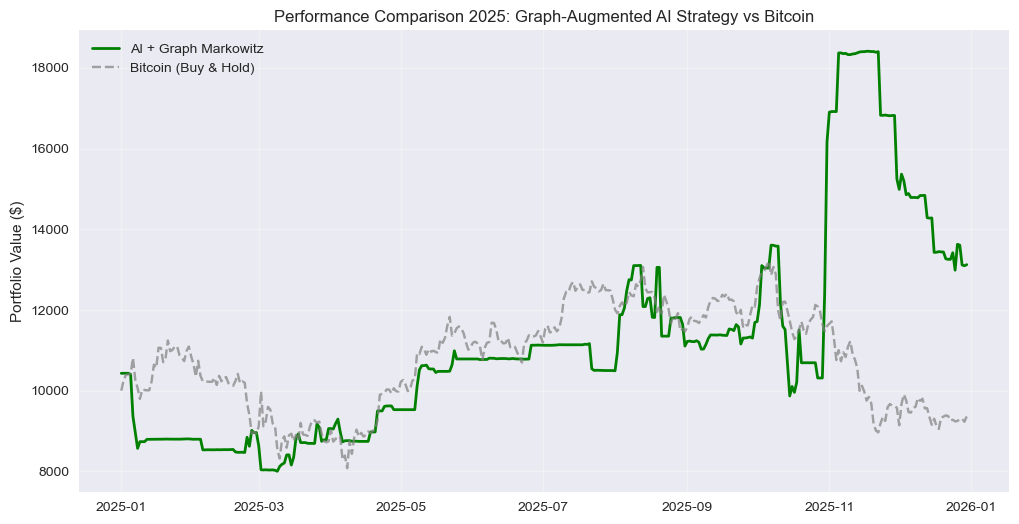

Strategy Total Return: 31.22%
Bitcoin Total Return: -6.34%
Strategy Max Value: $18410.20
Strategy Min Value: $8001.44


In [6]:
# Buat DataFrame Hasil
res_df = pd.DataFrame(history).set_index('Date')
res_df.index = pd.to_datetime(res_df.index)

# Benchmark (BTC Buy & Hold)
btc_2025 = data['BTC-USD'].loc[res_df.index]
btc_norm = btc_2025 / btc_2025.iloc[0] * initial_capital

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(res_df.index, res_df['Value'], label='AI + Graph Markowitz', color='green', linewidth=2)
plt.plot(btc_norm.index, btc_norm, label='Bitcoin (Buy & Hold)', color='gray', linestyle='--', alpha=0.7)

plt.title('Performance Comparison 2025: Graph-Augmented AI Strategy vs Bitcoin')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Metrics
final_val = res_df['Value'].iloc[-1]
total_return = (final_val - initial_capital) / initial_capital * 100
btc_return = (btc_norm.iloc[-1] - initial_capital) / initial_capital * 100

print(f"Strategy Total Return: {total_return:.2f}%")
print(f"Bitcoin Total Return: {btc_return:.2f}%")
print(f"Strategy Max Value: ${res_df['Value'].max():.2f}")
print(f"Strategy Min Value: ${res_df['Value'].min():.2f}")

### Analisis Detail (Regime & Diversification)
Mari kita lihat bagaimana portofolio berperilaku dalam fase yang berbeda. Apakah graf benar-benar mengurangi aset saat korelasi tinggi?

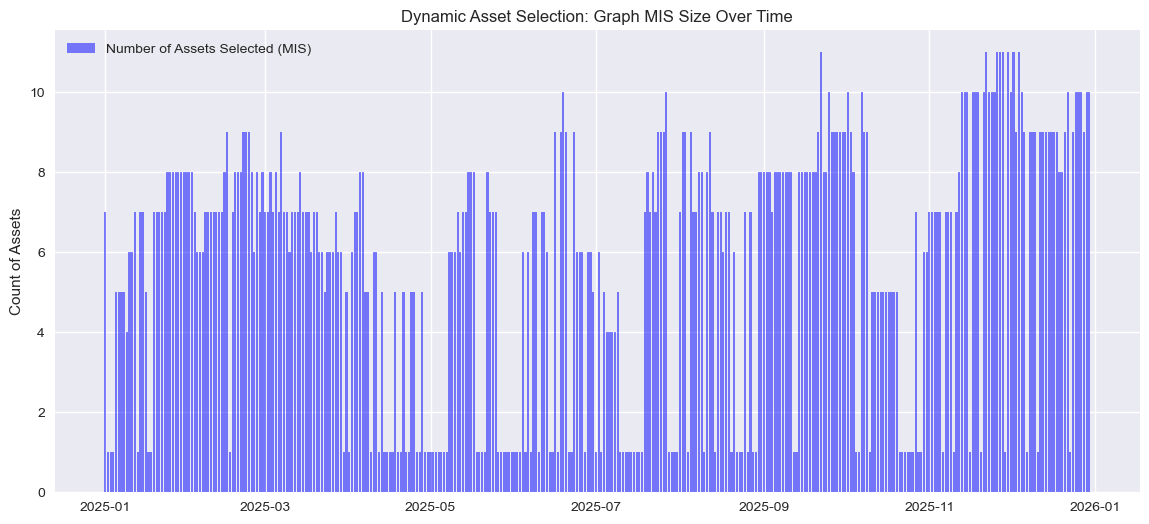

Sample Date: 2025-07-02
Regime: BULL
Assets Held: USDC-USD,DAI-USD,XMR-USD,UNI7083-USD,SHIB-USD,BCH-USD


In [7]:
plt.figure(figsize=(14, 6))
plt.bar(res_df.index, res_df['Num_Assets'], color='blue', alpha=0.5, label='Number of Assets Selected (MIS)')
plt.title('Dynamic Asset Selection: Graph MIS Size Over Time')
plt.ylabel('Count of Assets')
plt.legend()
plt.show()

# Cek sampel aset di tanggal tertentu
sample_row = res_df.iloc[len(res_df)//2]
print(f"Sample Date: {sample_row.name.date()}")
print(f"Regime: {sample_row['Regime']}")
print(f"Assets Held: {sample_row['Selected_Assets']}")